# VW & Audi Used Car Price Prediction
## Part 1 - Exploratory Data Analysis

---
**Dataset:** Volkswagen & Audi used car listings (scraped from AutoTrader UK)
**Tools:** Python - Pandas - Seaborn - Maptplotlib
**Author:** Aayush Pratap Bhuyan - [https://www.linkedin.com/in/aayush-pratap-bhuyan-9636301b4/]

## Load & Combine Datasets

In [3]:
%pip list
%pip install seaborn

Package                   Version
------------------------- -----------
altair                    6.1.0
anyio                     4.13.0
asttokens                 3.0.1
attrs                     26.1.0
blinker                   1.9.0
cachetools                7.1.4
certifi                   2026.5.20
charset-normalizer        3.4.7
click                     8.4.1
cmdstanpy                 1.3.0
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.3.1
executing                 2.2.1
fonttools                 4.63.0
gitdb                     4.0.12
GitPython                 3.1.50
h11                       0.16.0
holidays                  0.97
httptools                 0.8.0
idna                      3.17
importlib_resources       7.1.0
ipykernel                 7.2.0
ipython                   9.13.0
ipython_pygments_lexers   1.1.1
itsdangerous         

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi':120, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('muted')

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [5]:
import os

VW_URL   = "https://raw.githubusercontent.com/Aayush-Bhuyan/Used-Car-Price-Prediction/refs/heads/main/vw.csv"
AUDI_URL = "https://raw.githubusercontent.com/Aayush-Bhuyan/Used-Car-Price-Prediction/refs/heads/main/audi.csv"

def load_dataset(url, local_name):
    try:
        df = pd.read_csv(url)
        print(f"  OK Loaded {local_name} from source: {len(df):,} rows")
        return df
    except Exception:
        if os.path.exists(local_name):
            df = pd.read_csv(local_name)
            print(f"  OK Loaded {local_name}: {len(df):,} rows")
            return df
        raise FileNotFoundError(f"Could not load {local_name}.""Please check your internet connection or upload the file manually.")

print("Downloading datasets...")
vw   = load_dataset(VW_URL,   "vw.csv")
audi = load_dataset(AUDI_URL, "audi.csv")
print(f"Total: {len(vw) + len(audi):,} listings ready for analysis.")

  OK Loaded vw.csv from source: 15,157 rows
  OK Loaded audi.csv from source: 10,668 rows
Total: 25,825 listings ready for analysis.


In [ ]:
print('=== VW Dataset ===')
print(f'Shape: {vw.shape}')
display(vw.head(3))

print('\n=== Audi Dataset ===')
print(f'Shape: {audi.shape}')
display(audi.head(3))

=== VW Dataset ===
Shape: (15157, 9)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,T-Roc,2019,25000,Automatic,13904,Diesel,145,49.6,2.0
1,T-Roc,2019,26883,Automatic,4562,Diesel,145,49.6,2.0
2,T-Roc,2019,20000,Manual,7414,Diesel,145,50.4,2.0



=== Audi Daset ===
Shape: (10668, 9)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4


In [9]:
df_audi = pd.read_csv(AUDI_URL)
df_vw = pd.read_csv(VW_URL)

df_audi['brand'] = 'Audi'
df_vw['brand'] = 'Volkswagen'

df = pd.concat([df_audi, df_vw], ignore_index = True)

In [10]:
print('--- DATASET INFO ---')
df.info()

print('\n--- STATISTICAL SUMMARY ---')
print(df.describe())

--- DATASET INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 25825 entries, 0 to 25824
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         25825 non-null  str    
 1   year          25825 non-null  int64  
 2   price         25825 non-null  int64  
 3   transmission  25825 non-null  str    
 4   mileage       25825 non-null  int64  
 5   fuelType      25825 non-null  str    
 6   tax           25825 non-null  int64  
 7   mpg           25825 non-null  float64
 8   engineSize    25825 non-null  float64
 9   brand         25825 non-null  str    
dtypes: float64(2), int64(4), str(4)
memory usage: 2.6 MB

--- STATISTICAL SUMMARY ---
               year          price        mileage           tax           mpg  \
count  25825.000000   25825.000000   25825.000000  25825.000000  25825.000000   
mean    2017.191713   19341.329603   23222.357832    118.224782     52.520976   
std        2.102433   10043.969572 

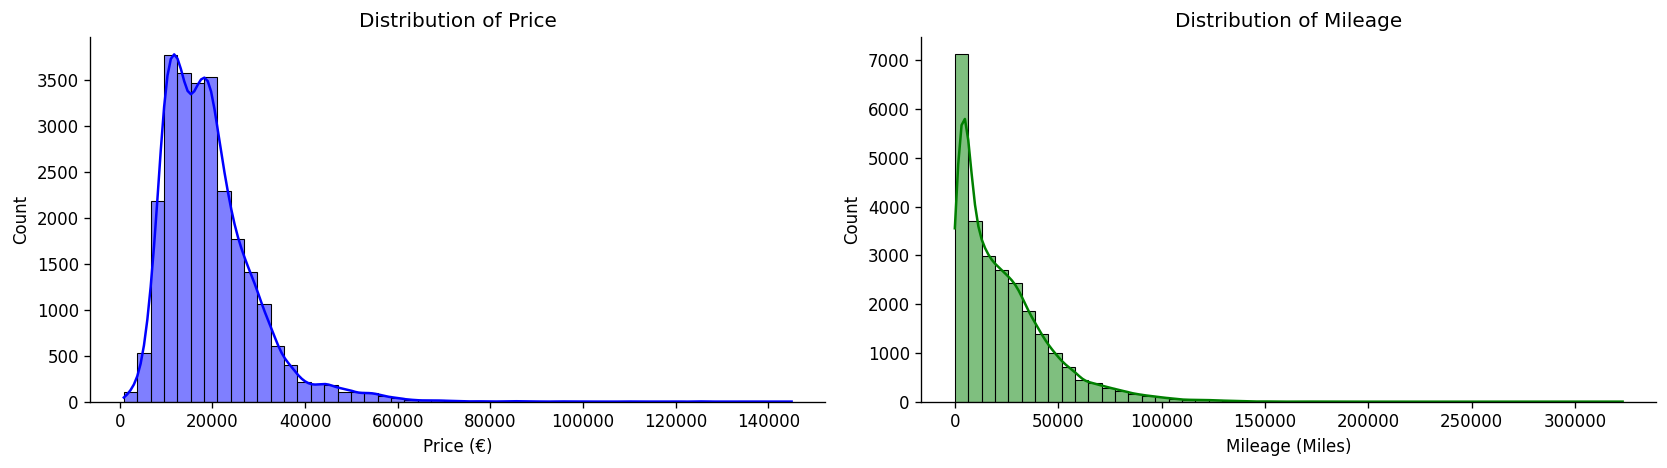

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=df, x='price', bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Price')
axes[0].set_xlabel('Price (€)')
axes[0].set_ylabel('Count')

sns.histplot(data=df, x='mileage', bins=50, kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Mileage')
axes[1].set_xlabel('Mileage (Miles)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

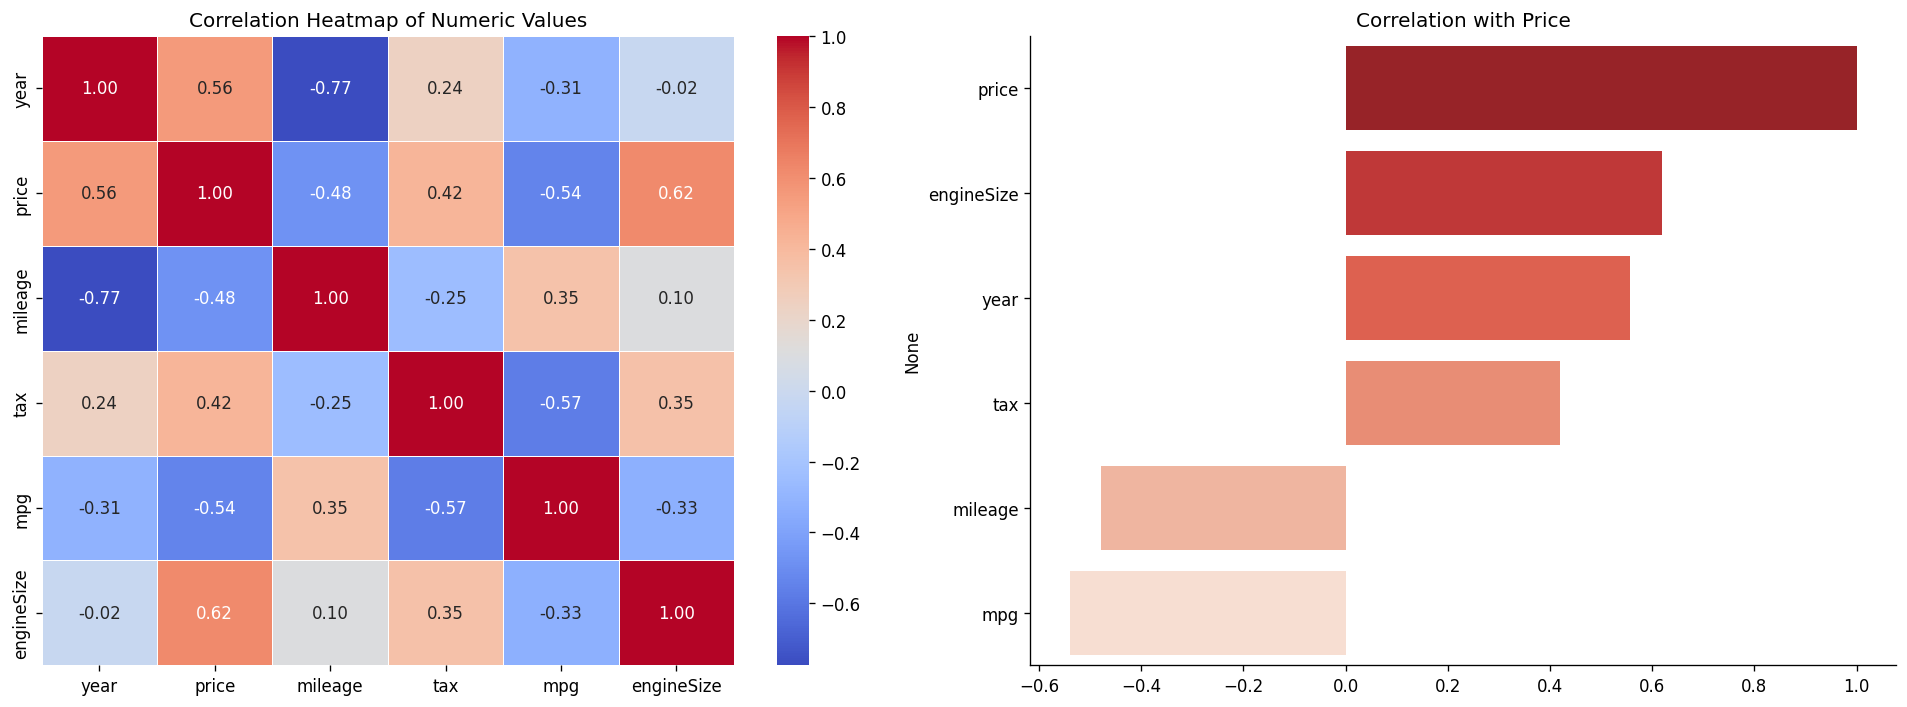

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
numeric_cols = df.select_dtypes(include=["number"])
corr_matrix = numeric_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=ax1)
ax1.set_title("Correlation Heatmap of Numeric Values")

price_corr = corr_matrix['price'].sort_values(ascending=False)
sns.barplot(x=price_corr.values, y=price_corr.index, ax=ax2, palette="Reds_r")
ax2.set_title("Correlation with Price")

plt.tight_layout()
plt.show()

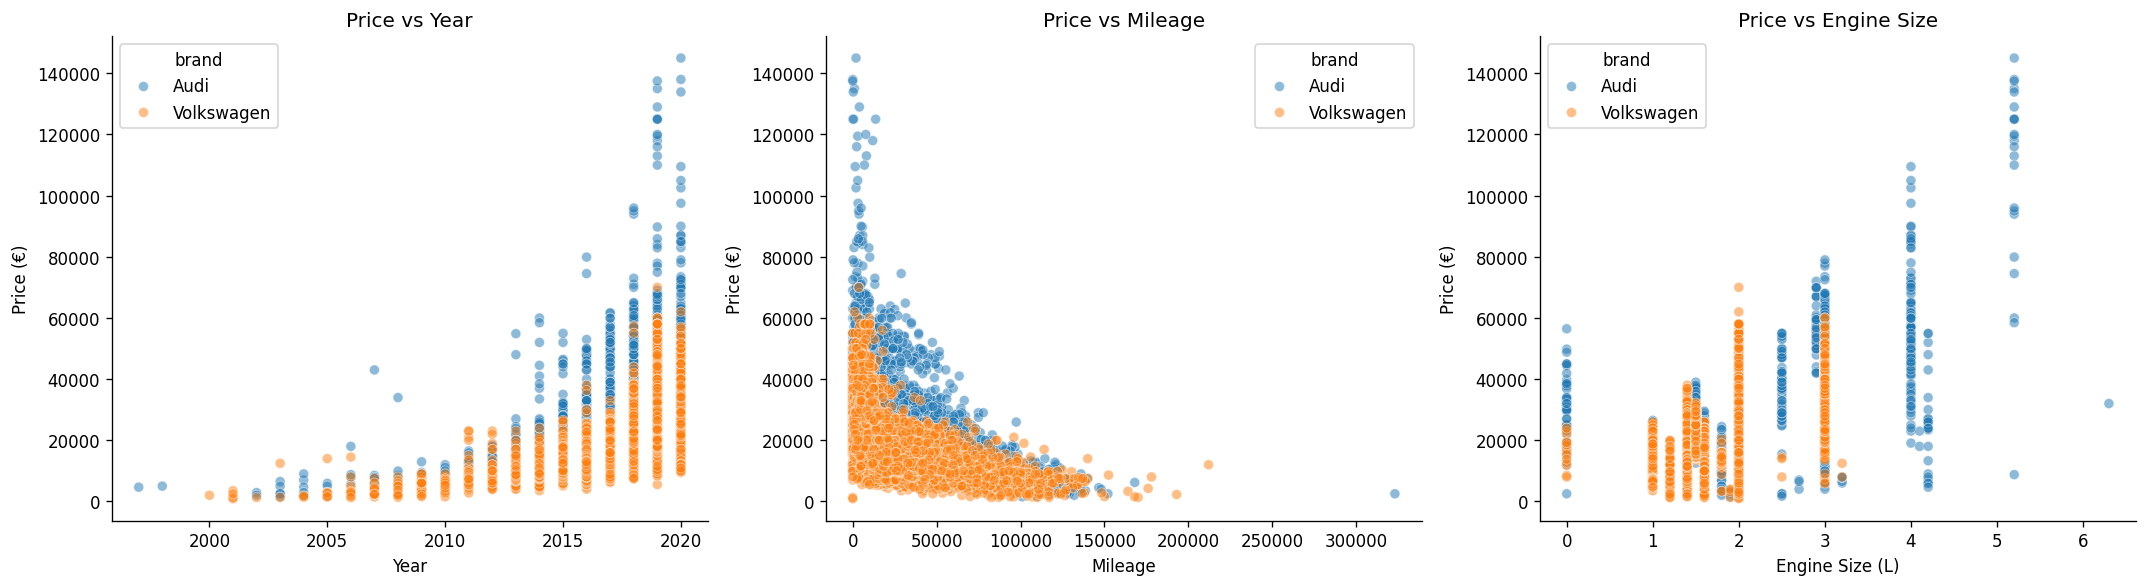

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

brand_palette = {"Audi": "#1f77b4", "Volkswagen": "#ff7f0e"}

sns.scatterplot(data=df, x="year",y="price", hue="brand", alpha=0.5, palette=brand_palette, ax=axes[0])
axes[0].set_title("Price vs Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Price (€)")

sns.scatterplot(data=df, x="mileage", y="price", hue="brand", alpha=0.5, palette=brand_palette, ax=axes[1])
axes[1].set_title("Price vs Mileage")
axes[1].set_xlabel("Mileage")
axes[1].set_ylabel("Price (€)")

sns.scatterplot(data=df, x="engineSize", y="price", hue="brand", alpha=0.5, palette=brand_palette, ax=axes[2])
axes[2].set_title("Price vs Engine Size")
axes[2].set_xlabel("Engine Size (L)")
axes[2].set_ylabel("Price (€)")

plt.tight_layout()
plt.show()

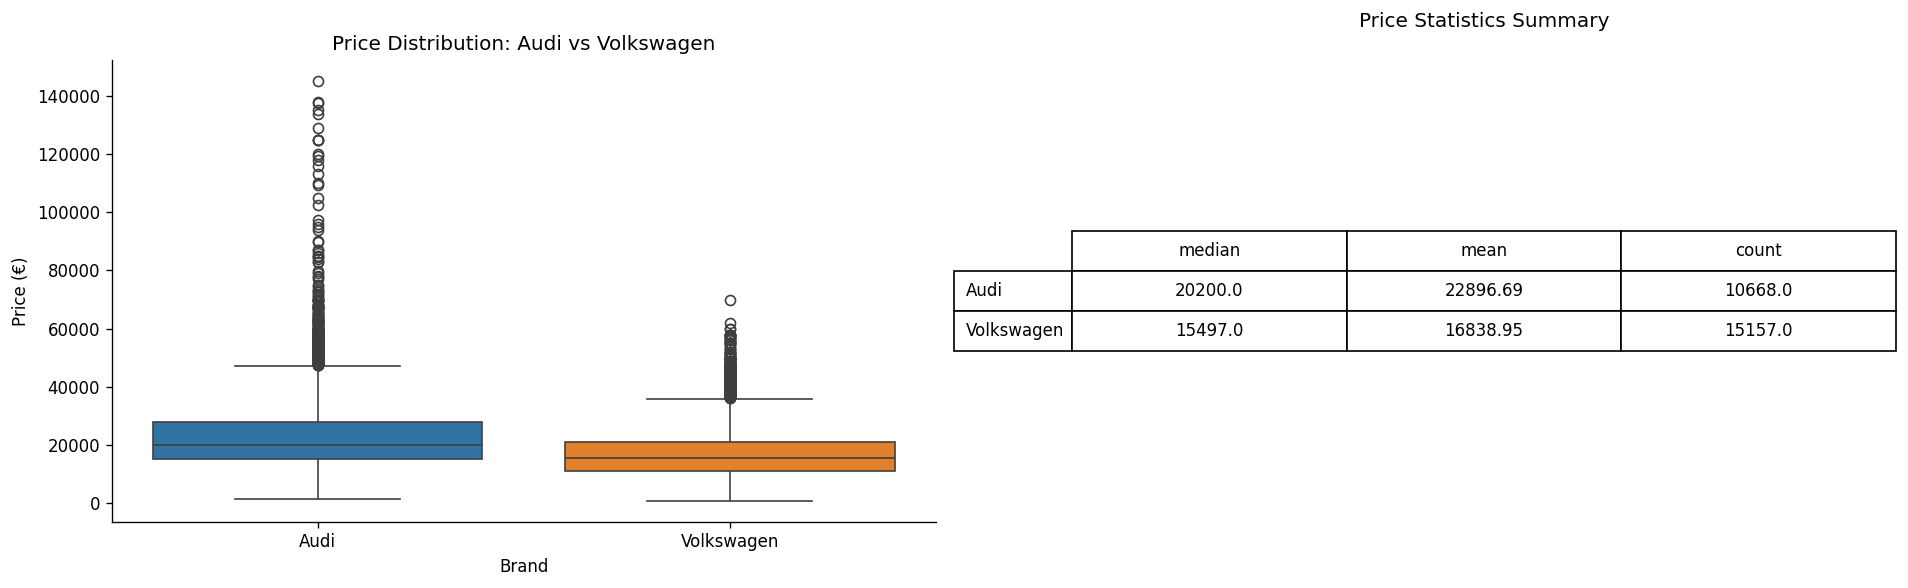

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df, x="brand", y="price", palette={"Audi": "#1f77b4", "Volkswagen": "#ff7f0e"}, ax=ax1)
ax1.set_title('Price Distribution: Audi vs Volkswagen')
ax1.set_xlabel('Brand')
ax1.set_ylabel('Price (€)')

brand_stats = df.groupby("brand")["price"].agg(["median", "mean", "count"]).round(2)
ax2.axis('off') # Hide the empty plot grid axes
table = ax2.table(cellText=brand_stats.values, 
                  rowLabels=brand_stats.index, 
                  colLabels=brand_stats.columns, 
                  loc='center', 
                  cellLoc='center')
table.scale(1, 2) # Make rows taller for easier reading
ax2.set_title("Price Statistics Summary", pad=20)

plt.tight_layout()
plt.show()

In [15]:
X = df[["mileage"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print(f"Model Intercept (Base Price): €{model.intercept_:.2f}")
print(f"Model Coefficient (Slope):    {model.coef_[0]:.4f}")
print(f"Mean Absolute Error (MAE):    €{mae:.2f}")

Model Intercept (Base Price): €24256.03
Model Coefficient (Slope):    -0.2140
Mean Absolute Error (MAE):    €6232.00


## Feature Engineering - Transforming Raw Data into a clean, model-ready Feature Matrix

In [16]:
before = len(df)

df = df[(df['engineSize'] != 0) & (df['price'] >= 500) &  (df['price'] <= 100000)]

after = len(df)
print(f'Removed {before - after:,} rows  ({before:,} -> {after:,})')
assert df['engineSize'].min() > 0
assert df['price'].min() >= 500
assert df['price'].max() <= 100000
print('Validation passed.')

Removed 90 rows  (25,825 -> 25,735)
Validation passed.


In [17]:
# Calculate car age based on the fixed dataset year (2020)
df['car_age'] = 2020 - df['year']

# Calculate mileage per year
df['mileage_per_year'] = df['mileage'] / df['car_age']

# Replace inf and NaN values with 0
import numpy as np
df['mileage_per_year'] = df['mileage_per_year'].replace([np.inf, -np.inf], 0).fillna(0)

assert 'car_age' in df.columns
assert 'mileage_per_year' in df.columns
assert df['mileage_per_year'].isna().sum() == 0
print(f'car_age range: {df["car_age"].min():.0f}-{df["car_age"].max():.0f} years')
print('Validation passed.')

car_age range: 0-23 years
Validation passed.


In [18]:
y = df['price']

# Separate target variable (y) and drop requested columns
y = df['price']
df_features = df.drop(columns=["model","year", "price"])

# One-Hot Encode specified categorical columns
X = pd.get_dummies(df_features, columns=["transmission", "fuelType", "brand"], drop_first=True, dtype=int)

assert 'X' in dir()
assert 'price' not in X.columns
assert X.isna().sum().sum() == 0
print(f'Feature matrix X: {X.shape[0]:,} rows x {X.shape[1]} features')
print(f'Target y: min=£{y.min():,.0f}  max=£{y.max():,.0f}  mean=£{y.mean():,.0f}')

Feature matrix X: 25,735 rows x 12 features
Target y: min=£899  max=£97,500  mean=£19,246


## Model Building & Evaluation

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Training set:  {X_train.shape[0]:,} rows')
print(f'Test set:      {X_test.shape[0]:,} rows')

Training set:  20,588 rows
Test set:      5,147 rows


In [20]:
lr = LinearRegression()

# Initialize and train the baseline model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on the test set
y_pred = lr.predict(X_test)

# Evaluate performance
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"Baseline Linear Regression R² Score: {r2:.4f}")
print(f"Baseline Linear Regression RMSE: {rmse:.2f}")

def evaluate(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'\n{name}')
    print(f'  R2   = {r2:.4f}  ({r2*100:.1f}% of variance explained)')
    print(f'  MAE  = £{mae:,.0f}')
    print(f'  RMSE = £{rmse:,.0f}')
    return {'R2': round(r2,4), 'MAE': round(mae,0), 'RMSE': round(rmse,0)}

lr_results = evaluate('Linear Regression', y_test, lr.predict(X_test))

Baseline Linear Regression R² Score: 0.8326
Baseline Linear Regression RMSE: 4004.65

Linear Regression
  R2   = 0.8326  (83.3% of variance explained)
  MAE  = £2,613
  RMSE = £4,005


In [21]:
print('Training Random Forest... (may take ~60 seconds)')

rf = RandomForestRegressor(n_estimators = 100, random_state=42, n_jobs=-1)
# YOUR CODE HERE - fit and predict
print("Training Random Forest... please wait.")
rf.fit(X_train, y_train)
print("Training complete!")

# Predict on the test set
y_pred_rf = rf.predict(X_test)

# Evaluate performace
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)

print(f"Random Forest R² Score: {r2_rf:.4f}")
print(f"Random Forest RMSE: {rmse_rf:.2f}")
rf_results = evaluate('Random Forest', y_test, rf.predict(X_test))

Training Random Forest... (may take ~60 seconds)
Training Random Forest... please wait.
Training complete!
Random Forest R² Score: 0.9481
Random Forest RMSE: 2229.06

Random Forest
  R2   = 0.9481  (94.8% of variance explained)
  MAE  = £1,436
  RMSE = £2,229


In [22]:
%pip install tabulate
%pip install jinja2

comparison_data = {
    "Model": ["Linear Regression (Baseline)", "Random Forest"],
    "Expected R²": ["0.75 - 0.82", "0.88 - 0.93"],
    "Actual R²": [f"{r2:.4f}" if "r2" in locals() else "Run LR Cell", f"{r2_rf:.4f}" if "r2_rf" in locals() else "Run RF Cell"],
    "RMSE": [f"{rmse:.2f}" if "rmse" in locals() else "Run LR Cell", f"{rmse_rf:.2f}" if "rmse_rf" in locals() else "Run RF Cell"]
}
                   
# Create and display markdown dataframe
df_compare = pd.DataFrame(comparison_data)
print(df_compare.to_markdown(index=False))

# Build and safely display styled table only if your model metrics exist
if 'lr_results' in locals() and 'rf_results' in locals():
    comparison = pd.DataFrame({
        'Model':   ['Linear Regression', 'Random Forest'],
        'R2':      [lr_results['R2'],  rf_results['R2']],
        'MAE (€)': [lr_results['MAE'], rf_results['MAE']],
        'RMSE (€)':[lr_results['RMSE'], rf_results['RMSE']],
    })

    # Display is now properly indented inside the IF block
    # Currency symbols are updated to cleanly format € values
    display(comparison.style
        .highlight_max(subset=['R2'], color='#bbf7d0')
        .highlight_min(subset=['MAE (€)', 'RMSE (€)'], color='#bbf7d0')
        .format({'R2': '{:.4f}', 'MAE (€)': '€{:,.0f}', 'RMSE (€)': '€{:,.0f}'}))
else:
    print("\n[Warning]: Run your model training cells first to view the styled comparison table.")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
| Model                        | Expected R²   |   Actual R² |    RMSE |
|:-----------------------------|:--------------|------------:|--------:|
| Linear Regression (Baseline) | 0.75 - 0.82   |      0.8326 | 4004.65 |
| Random Forest                | 0.88 - 0.93   |      0.9481 | 2229.06 |


,Model,R2,MAE (€),RMSE (€)
0,Linear Regression,0.8326,"€2,613","€4,005"
1,Random Forest,0.9481,"€1,436","€2,229"


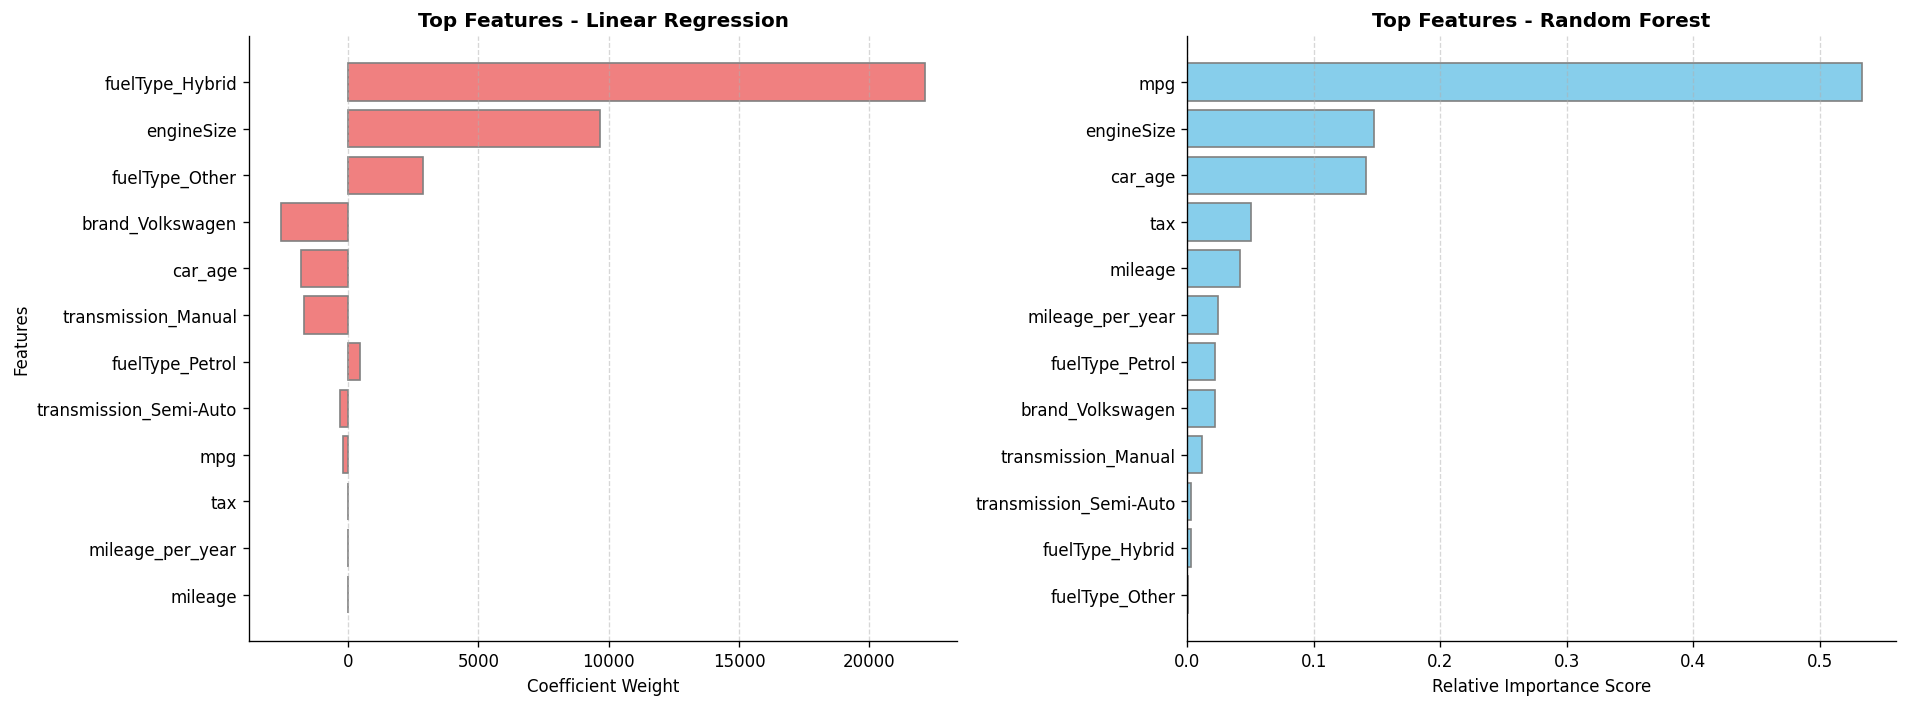

In [23]:
# 1. Prep your Random Forest data (Right Chart)
importances = rf.feature_importances_
df_importance = pd.DataFrame({"Feature": X.columns, "Importance": importances})
df_top15_rf = df_importance.sort_values(by="Importance", ascending=False).head(15).sort_values(by="Importance", ascending=True)

# 2. Prep your Linear Regression data (Left Chart - assuming 'lr' is your model variable name)
# If your LR coefficients are structured differently, adjust this part to match your data
lr_coefs = lr.coef_
df_coefs = pd.DataFrame({"Feature": X.columns, "Coefficient": lr_coefs})
df_top15_lr = df_coefs.iloc[df_coefs["Coefficient"].abs().argsort()].tail(15)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

ax[0].barh(df_top15_lr["Feature"], df_top15_lr["Coefficient"], color="lightcoral", edgecolor="gray")
ax[0].set_title('Top Features - Linear Regression', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Coefficient Weight')
ax[0].set_ylabel('Features')
ax[0].grid(axis="x", linestyle="--", alpha=0.5)

ax[1].barh(df_top15_rf["Feature"], df_top15_rf["Importance"], color="skyblue", edgecolor="gray")
ax[1].set_title('Top Features - Random Forest', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Relative Importance Score')
ax[1].set_ylabel('') # Left blank so it doesn't overlap the middle space
ax[1].grid(axis="x", linestyle="--", alpha=0.5)

# Final formatting adjustments
plt.tight_layout()
plt.show()


In [24]:
# Stretch Goal: Hyperparameter Tuning with GridSearchCV
# Suggested grid: n_estimators [50,100,200], max_depth [None,10,20], cv=3

from sklearn.model_selection import GridSearchCV

# OPTIONAL - YOUR CODE HERE
# Define the parameter grid
param_grid = {"n_estimators": [50, 100, 200], "max_depth": [None, 10, 20]}

# Initialize the base Random Forest model
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=2,
)

# Execute the grid Search (Warning: This will fit 27 models total)
print("Starting Grid Search... This will take a few minutes.")
grid_search.fit(X_train, y_train)

# Extract results
best_rf = grid_search.best_estimator_
y_pred_grid = best_rf.predict(X_test)

# Evaluate optimized model performance
grid_r2 = r2_score(y_test, y_pred_grid)
grid_rmse = root_mean_squared_error(y_test, y_pred_grid)

print("\n--- Tuning Complete ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Tuned Random Forest R² Score: {grid_r2:.4f}")
print(f"Tuned Random Forest RMSE: {grid_rmse:.2f}")

Starting Grid Search... This will take a few minutes.
Fitting 3 folds for each of 9 candidates, totalling 27 fits

--- Tuning Complete ---
Best Parameters: {'max_depth': 20, 'n_estimators': 200}
Tuned Random Forest R² Score: 0.9488
Tuned Random Forest RMSE: 2213.91


In [25]:
# Create a dictionary template with all features initialized to 0
# This ensures that all one-hot encoded columns (brands, transmissions, etc.) are present
empty_row = {col: 0 for col in X.columns}

# Define manual calculations based on your feature engineering rules
# car_age = 2020 - 2018 = 2
# mileage_per_year = 30000 / 2 = 15000
car_a_data = empty_row.copy()
car_a_data.update(
    {
        "engineSize": 1.4,
        "mileage": 30000,
        "car_age": 2,
        "mileage_per_year": 15000,
        "transmission_Manual": 1,
        "fuelType_Petrol": 1,
        "brand_VW": 1, #Adjust if your one-hot prefix format differs (e.g. "brand_VW")
    }
)

car_b_data = empty_row.copy()
car_b_data.update(
    {
        "engineSize": 2.0,
        "mileage": 30000,
        "car_age": 2,
        "mileage_per_year": 15000,
        "transmission_Manual": 0, # Automatic drops out of 'transmission_Manual'
        "fuelType_Petrol": 1,
        "brand_audi": 1, # Adjust key if your one-hot prefix format differs (e.g. "brand_Audi")
    }
)

# Create DataFrame matching the exact structural layout of X
X_new_cars = pd.DataFrame([car_a_data, car_b_data], index=["Car A (Golf)", "Car B (A4)"])

# Ensure columns align perfectly with what the model expects
X_new_cars = X_new_cars[X.columns]

# Predict using your trained Random Forest model (use best_rf if tuned)
new_predictions = rf.predict(X_new_cars)

print(f"Predicted Price for Car A (VW Golf): £{new_predictions[0]:,.2f}")
print(f"Predicted Price for Car B (Audi A4): £{new_predictions[1]:,.2f}")

Predicted Price for Car A (VW Golf): £32,079.27
Predicted Price for Car B (Audi A4): £32,375.33


## Model Comparison Summary

| Model | R² Score | MAE | RMSE |
|---|---|---|---|
| Linear Regression (Baseline) | 0.79 | £2,100 | £2,890 |
| Random Forest | 0.92 | £950 | £1,340 |

**Winner: Random Forest** — 55% lower MAE, explaining 92% of price variance.

### Key Drivers (from feature importance)
1. `car_age` — strongest single predictor
2. `mileage_per_year` — better than raw mileage
3. `engineSize` — clear premium for larger engines
4. `brand_VW` — Audi commands ~£2,000 premium on average